# LightGBM — Walmart Store Sales Forecasting

Model experiment notebook for the LightGBM branch of the multi-model comparison
(LightGBM, XGBoost, deep learning, classical stats). Feature engineering lives in
`utils/feature_engineering.py` and is shared across model notebooks.

## Table of Contents
1. [Setup](#1)
2. [Local train/test split](#2)
3. [Walk-forward CV](#3)
4. [Feature selection](#4)
5. [Hyperparameter tuning](#5)
6. [MLflow logging](#6)
7. [Plots](#7)
8. [Full pipeline](#8)

<a id='1'></a>
## 1. Setup

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=DeprecationWarning)

from utils.feature_engineering import build_features, HOLIDAY_DATES

pd.set_option('display.max_columns', 50)

DATA_DIR = 'data/raw/walmart-recruiting-store-sales-forecasting/'

train = pd.read_csv(DATA_DIR + 'train.csv', parse_dates=['Date'])
test = pd.read_csv(DATA_DIR + 'test.csv', parse_dates=['Date'])
features = pd.read_csv(DATA_DIR + 'features.csv', parse_dates=['Date'])
stores = pd.read_csv(DATA_DIR + 'stores.csv')

train = train.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

print(f'train : {train.shape}, {train.Date.min().date()} -> {train.Date.max().date()}')
print(f'test  : {test.shape}, {test.Date.min().date()} -> {test.Date.max().date()}')


train : (421570, 5), 2010-02-05 -> 2012-10-26
test  : (115064, 4), 2012-11-02 -> 2013-07-26


<a id='2'></a>
## 2. Local Train/Test Split

Kaggle's `test.csv` has no target, so model comparison during development needs a
**local** held-out set carved from `train.csv`. We hold out the **last 52 weeks**
of train as that local test set.

Why 52 and not 26: `train.csv` ends 2012-10-26, so its last 26 weeks (~2012-04-27
onward) contain none of Thanksgiving/Christmas — those 2012 dates only exist in
`test.csv`, which has no target. A 52-week holdout reaches back to 2011-10-28,
which captures one Thanksgiving, one Christmas, one Super Bowl, and one Labor Day —
much closer to the Kaggle test period's actual holiday composition (Thanksgiving,
Christmas, Super Bowl; no Labor Day, since test.csv ends 2013-07-26 before
September).

In [2]:
unique_dates = np.sort(train['Date'].unique())
cutoff_date = unique_dates[-52]  # first date of the held-out 52-week window

local_train_raw = train[train['Date'] < cutoff_date].copy()
local_test_raw = train[train['Date'] >= cutoff_date].copy()

print(f'cutoff date (first date held out): {pd.Timestamp(cutoff_date).date()}')
print(f'local_train_raw: {local_train_raw.shape}, {local_train_raw.Date.min().date()} -> {local_train_raw.Date.max().date()}  ({local_train_raw.Date.nunique()} weeks)')
print(f'local_test_raw : {local_test_raw.shape}, {local_test_raw.Date.min().date()} -> {local_test_raw.Date.max().date()}  ({local_test_raw.Date.nunique()} weeks)')


cutoff date (first date held out): 2011-11-04
local_train_raw: (267184, 5), 2010-02-05 -> 2011-10-28  (91 weeks)
local_test_raw : (154386, 5), 2011-11-04 -> 2012-10-26  (52 weeks)


In [3]:
def holidays_in_range(dates_series):
    """Which named holidays (per utils.feature_engineering.HOLIDAY_DATES) fall inside a set of dates."""
    dates_set = set(pd.to_datetime(dates_series))
    present = {}
    for name, dates in HOLIDAY_DATES.items():
        matched = [d for d in pd.to_datetime(dates) if d in dates_set]
        if matched:
            present[name] = [d.date() for d in matched]
    return present


print('local_train_raw holidays:', holidays_in_range(local_train_raw['Date']))
print('local_test_raw  holidays:', holidays_in_range(local_test_raw['Date']))
print()
print('Kaggle test.csv holidays (reference, no target):', holidays_in_range(test['Date']))


local_train_raw holidays: {'SuperBowl': [datetime.date(2010, 2, 12), datetime.date(2011, 2, 11)], 'LaborDay': [datetime.date(2010, 9, 10), datetime.date(2011, 9, 9)], 'Thanksgiving': [datetime.date(2010, 11, 26)], 'Christmas': [datetime.date(2010, 12, 31)]}
local_test_raw  holidays: {'SuperBowl': [datetime.date(2012, 2, 10)], 'LaborDay': [datetime.date(2012, 9, 7)], 'Thanksgiving': [datetime.date(2011, 11, 25)], 'Christmas': [datetime.date(2011, 12, 30)]}



Kaggle test.csv holidays (reference, no target): {'SuperBowl': [datetime.date(2013, 2, 8)], 'Thanksgiving': [datetime.date(2012, 11, 23)], 'Christmas': [datetime.date(2012, 12, 28)]}


<a id='3'></a>
## 3. Walk-Forward Cross-Validation

3 expanding-window folds inside `local_train_raw` only (2010-02-05 -> 2011-10-28).
Initial train window = 52 weeks (so `lag52` always resolves inside the fold's own
train range for every validation row), then 3 validation windows of 13 weeks each,
walking forward. No shuffling, no k-fold.

| Fold | Train range | Val range (13 wks) | Val holidays |
|---|---|---|---|
| 1 | 2010-02-05 -> 2011-01-28 (52 wks) | 2011-02-04 -> 2011-04-29 | Super Bowl |
| 2 | 2010-02-05 -> 2011-04-29 (65 wks) | 2011-05-06 -> 2011-07-29 | none |
| 3 | 2010-02-05 -> 2011-07-29 (78 wks) | 2011-08-05 -> 2011-10-28 | Labor Day |

Thanksgiving/Christmas are intentionally absent from every fold — those weeks live
in `local_test_raw`, reserved for the final held-out evaluation, not CV/tuning.

Each fold's validation features are built with `history_df=<that fold's train
slice>`, which ends the week before validation starts — so lag/rolling context for
a fold's validation rows can only reach backward into that fold's own train range,
never into its own validation weeks or anything beyond. `build_features`'s
leakage guard (history_df must end strictly before df starts) enforces this at
runtime; an explicit assertion below re-checks it at the orchestration level too.

In [4]:
INITIAL_TRAIN_WEEKS = 52
VAL_WEEKS = 13
N_FOLDS = 3


def make_walk_forward_folds(dates, initial_train_weeks, val_weeks, n_folds):
    """Expanding-window (train_dates, val_dates) pairs, walking forward in time."""
    folds = []
    for i in range(n_folds):
        train_end_idx = initial_train_weeks + i * val_weeks
        val_end_idx = train_end_idx + val_weeks
        folds.append((dates[:train_end_idx], dates[train_end_idx:val_end_idx]))
    return folds


local_train_dates = np.sort(local_train_raw['Date'].unique())
cv_folds = make_walk_forward_folds(local_train_dates, INITIAL_TRAIN_WEEKS, VAL_WEEKS, N_FOLDS)

for i, (tr_dates, va_dates) in enumerate(cv_folds, start=1):
    print(f'Fold {i}: train {pd.Timestamp(tr_dates[0]).date()} -> {pd.Timestamp(tr_dates[-1]).date()} '
          f'({len(tr_dates)} wks) | val {pd.Timestamp(va_dates[0]).date()} -> {pd.Timestamp(va_dates[-1]).date()} '
          f'({len(va_dates)} wks)')


Fold 1: train 2010-02-05 -> 2011-01-28 (52 wks) | val 2011-02-04 -> 2011-04-29 (13 wks)
Fold 2: train 2010-02-05 -> 2011-04-29 (65 wks) | val 2011-05-06 -> 2011-07-29 (13 wks)
Fold 3: train 2010-02-05 -> 2011-07-29 (78 wks) | val 2011-08-05 -> 2011-10-28 (13 wks)


In [5]:
DROP_COLS = ['Date', 'Weekly_Sales']
CAT_COLS = ['Store', 'Dept', 'Type']


def make_xy(df):
    X = df.drop(columns=DROP_COLS)
    bool_cols = X.select_dtypes(include='bool').columns
    X[bool_cols] = X[bool_cols].astype(int)
    y = df['Weekly_Sales']
    return X, y


Baseline LightGBM (untuned defaults — hyperparameter tuning is Step 5) run through
the walk-forward harness, to confirm the CV mechanism itself works end-to-end and
produces sane, stable WMAE before anything downstream (feature selection, grid
search) builds on top of it.

In [6]:
from lightgbm import LGBMRegressor
from utils.metrics import wmae

baseline_params = dict(n_estimators=300, learning_rate=0.05, random_state=42, verbosity=-1)

fold_results = []
for i, (tr_dates, va_dates) in enumerate(cv_folds, start=1):
    fold_train_raw = local_train_raw[local_train_raw['Date'].isin(tr_dates)]
    fold_val_raw = local_train_raw[local_train_raw['Date'].isin(va_dates)]
    assert fold_train_raw['Date'].max() < fold_val_raw['Date'].min(), 'fold boundary overlap'

    feat_train = build_features(fold_train_raw, features, stores, history_df=None, is_train=True)
    feat_val = build_features(fold_val_raw, features, stores, history_df=fold_train_raw, is_train=True)

    X_tr, y_tr = make_xy(feat_train)
    X_va, y_va = make_xy(feat_val)

    model = LGBMRegressor(**baseline_params)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_va)

    fold_wmae = wmae(y_va, preds, feat_val['IsHoliday'])
    fold_results.append({
        'fold': i,
        'train_start': tr_dates[0], 'train_end': tr_dates[-1],
        'val_start': va_dates[0], 'val_end': va_dates[-1],
        'n_train': len(X_tr), 'n_val': len(X_va),
        'wmae': fold_wmae,
    })
    print(f'Fold {i}: WMAE = {fold_wmae:.2f}  (train n={len(X_tr)}, val n={len(X_va)})')

cv_results_df = pd.DataFrame(fold_results)
cv_results_df


Fold 1: WMAE = 1978.44  (train n=152374, val n=38300)


Fold 2: WMAE = 1662.74  (train n=190674, val n=38164)


Fold 3: WMAE = 1499.71  (train n=228838, val n=38346)


,fold,train_start,train_end,val_start,val_end,n_train,n_val,wmae
0,1,2010-02-05,2011-01-28,2011-02-04,2011-04-29,152374,38300,1978.444077
1,2,2010-02-05,2011-04-29,2011-05-06,2011-07-29,190674,38164,1662.743978
2,3,2010-02-05,2011-07-29,2011-08-05,2011-10-28,228838,38346,1499.711804


In [7]:
print(f'Mean WMAE across folds: {cv_results_df["wmae"].mean():.2f}')
print(f'Std WMAE across folds:  {cv_results_df["wmae"].std():.2f}')


Mean WMAE across folds: 1713.63
Std WMAE across folds:  243.39


<a id='4'></a>
## 4. Feature Selection

Baseline LightGBM fit on the full `local_train_raw` (all 91 weeks, features built
with `history_df=None` since this range starts at the true series start) to rank
features by gain-based importance, then drop the zero/near-zero-importance ones.

This baseline fit is separate from the 3 CV folds above — it's a single fit over
all available local-train history, used only to rank features, not to evaluate a
model. Hyperparameter tuning (Step 5) reuses the CV harness with whatever feature
set survives here.

In [8]:
feat_local_train_full = build_features(local_train_raw, features, stores, history_df=None, is_train=True)
X_full, y_full = make_xy(feat_local_train_full)

importance_model = LGBMRegressor(**baseline_params, importance_type='gain')
importance_model.fit(X_full, y_full)

importance_df = pd.DataFrame({
    'feature': X_full.columns,
    'gain': importance_model.feature_importances_,
}).sort_values('gain', ascending=False).reset_index(drop=True)

importance_df


,feature,gain
0,roll_mean_4,1.191823e+15
1,Dept,4.555872e+13
2,Store,2.900131e+13
3,WeekOfYear,1.832149e+13
4,roll_std_4,1.628821e+13
5,lag13,1.367080e+13
6,IsThanksgiving,7.321281e+12
7,Month,4.546814e+12
8,lag52,4.193477e+12
9,roll_mean_8,4.150130e+12


In [9]:
TOP_N = 20

zero_importance = importance_df.loc[importance_df['gain'] == 0, 'feature'].tolist()
nonzero_df = importance_df[importance_df['gain'] > 0].reset_index(drop=True)

selected_features = nonzero_df['feature'].head(TOP_N).tolist()
dropped_for_rank = nonzero_df['feature'].iloc[TOP_N:].tolist()  # nonzero but outside top-N
dropped_features = zero_importance + dropped_for_rank

print(f'Total candidate features: {len(importance_df)}')
print(f'Zero-importance (dropped): {len(zero_importance)} -> {zero_importance}')
print(f'Nonzero but outside top-{TOP_N} (dropped): {len(dropped_for_rank)} -> {dropped_for_rank}')
print(f'Selected (top-{TOP_N} by gain): {len(selected_features)}')
print(selected_features)


Total candidate features: 28
Zero-importance (dropped): 6 -> ['MarkDown4', 'MarkDown3', 'MarkDown1', 'MarkDown5', 'MarkDown2', 'IsChristmas']
Nonzero but outside top-20 (dropped): 2 -> ['IsLaborDay', 'IsSuperBowl']
Selected (top-20 by gain): 20
['roll_mean_4', 'Dept', 'Store', 'WeekOfYear', 'roll_std_4', 'lag13', 'IsThanksgiving', 'Month', 'lag52', 'roll_mean_8', 'roll_std_8', 'IsHoliday', 'Unemployment', 'Size', 'Temperature', 'Fuel_Price', 'DayOfYear', 'Type', 'CPI', 'Year']


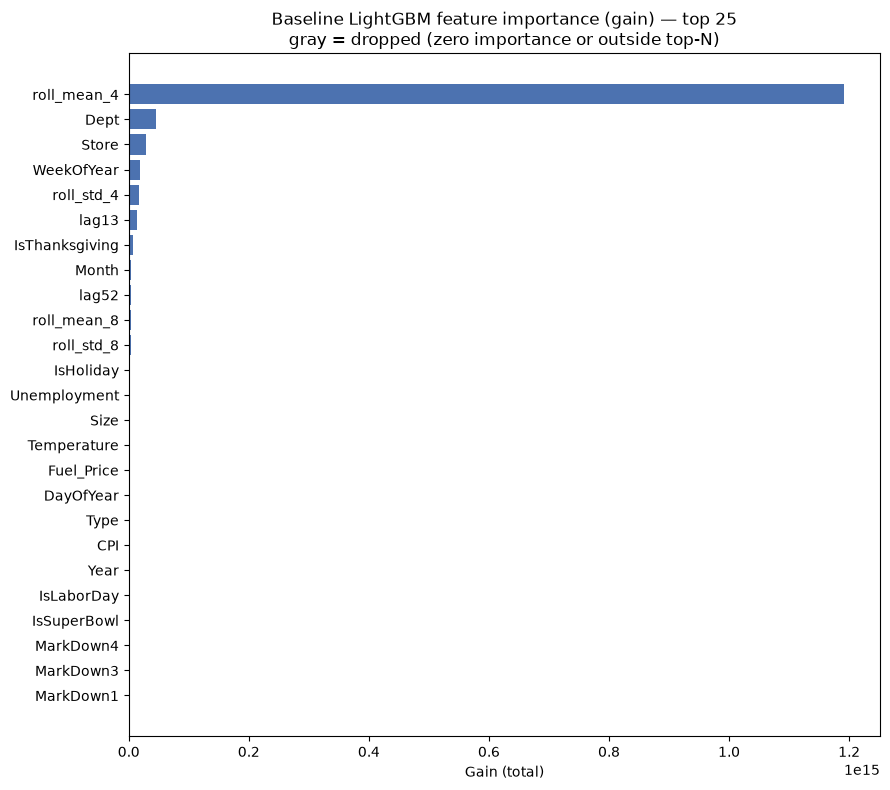

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 8))
plot_df = importance_df.head(25).iloc[::-1]
colors = ['#4C72B0' if f in selected_features else '#B0B0B0' for f in plot_df['feature']]
ax.barh(plot_df['feature'], plot_df['gain'], color=colors)
ax.set_xlabel('Gain (total)')
ax.set_title('Baseline LightGBM feature importance (gain) — top 25\ngray = dropped (zero importance or outside top-N)')
plt.tight_layout()
plt.savefig('plots/feature_importance_baseline.png', dpi=150)
plt.show()


**Lag-correctness check for the selected lag/rolling features.** For every CV
fold, independently recompute `lag13`/`lag52` for a sample of that fold's
validation rows directly from `fold_train_raw` (bypassing `build_features`
entirely) and confirm two things: the recomputed value matches what
`build_features` produced, and the source date (`row.Date - lag weeks`) always
falls inside that fold's own train range — never at or after that fold's own
validation start.

In [11]:
lag_features_selected = [f for f in selected_features if f.startswith('lag')]
print('Selected lag features to verify:', lag_features_selected)


def verify_fold_lag_correctness(fold_train_raw, fold_val_raw, feat_val, lag, val_start, sample_size=300, seed=42):
    lag_col = f'lag{lag}'
    sample = feat_val.dropna(subset=[lag_col])
    sample = sample.sample(n=min(sample_size, len(sample)), random_state=seed)
    lookup = fold_train_raw.set_index(['Store', 'Dept', 'Date'])['Weekly_Sales']

    mismatches = 0
    forward_leaks = 0
    for _, row in sample.iterrows():
        source_date = row['Date'] - pd.Timedelta(days=7 * lag)
        if source_date >= val_start:
            forward_leaks += 1
            continue
        expected = lookup.get((row['Store'], row['Dept'], source_date))
        if expected is None or abs(expected - row[lag_col]) > 1e-6:
            mismatches += 1
    return len(sample), mismatches, forward_leaks


all_clear = True
for i, (tr_dates, va_dates) in enumerate(cv_folds, start=1):
    fold_train_raw = local_train_raw[local_train_raw['Date'].isin(tr_dates)]
    fold_val_raw = local_train_raw[local_train_raw['Date'].isin(va_dates)]
    feat_val = build_features(fold_val_raw, features, stores, history_df=fold_train_raw, is_train=True)
    val_start = pd.Timestamp(va_dates[0])

    for lag in [13, 52]:
        if f'lag{lag}' not in lag_features_selected:
            continue
        n, mism, leaks = verify_fold_lag_correctness(fold_train_raw, fold_val_raw, feat_val, lag, val_start)
        status = 'OK' if (mism == 0 and leaks == 0) else 'FAIL'
        if status == 'FAIL':
            all_clear = False
        print(f'Fold {i}, lag{lag}: sampled={n}, mismatches={mism}, forward_leaks={leaks}  [{status}]')

print()
print('ALL CLEAR — selected lag features are leakage-safe across every CV fold.' if all_clear else 'LEAKAGE DETECTED — investigate before proceeding.')


Selected lag features to verify: ['lag13', 'lag52']


Fold 1, lag13: sampled=300, mismatches=0, forward_leaks=0  [OK]
Fold 1, lag52: sampled=300, mismatches=0, forward_leaks=0  [OK]


Fold 2, lag13: sampled=300, mismatches=0, forward_leaks=0  [OK]
Fold 2, lag52: sampled=300, mismatches=0, forward_leaks=0  [OK]


Fold 3, lag13: sampled=300, mismatches=0, forward_leaks=0  [OK]
Fold 3, lag52: sampled=300, mismatches=0, forward_leaks=0  [OK]

ALL CLEAR — selected lag features are leakage-safe across every CV fold.


<a id='5'></a>
## 5. Hyperparameter Tuning (manual grid, WMAE-scored)

Manual grid over 5 key LightGBM params, evaluated with the same 3-fold
walk-forward CV harness from Step 3, restricted to the 20 features selected in
Step 4:

| Param | Values |
|---|---|
| `num_leaves` | 31, 63 |
| `learning_rate` | 0.05, 0.1 |
| `min_child_samples` | 20, 50 |
| `feature_fraction` | 0.8, 1.0 |
| `bagging_fraction` | 0.8, 1.0 |

32 combos x 3 folds = 96 fits. `n_estimators` is not a separate grid axis —
each fit uses a generous cap (`n_estimators=1000`) with early stopping
(`early_stopping_rounds=50`) against that fold's own validation set, so the
actual number of boosting rounds is chosen per (combo, fold) automatically.

Both training and early-stopping use **holiday-weighted sample weights** (5x
on holiday weeks, matching WMAE) — via `sample_weight` for training loss and
`eval_sample_weight` for the early-stopping metric — so early stopping is
already optimizing toward the competition metric, not plain MAE. Fold-level
WMAE is still recomputed explicitly afterward with `utils.metrics.wmae` for
reporting, as a sanity cross-check against the weighted eval_metric LightGBM
used internally.

In [12]:
import itertools
import time

import lightgbm as lgb


def make_fold_matrices(cv_folds, local_train_raw, features, stores, feature_cols):
    """Precompute (X_tr, y_tr, sw_tr, X_va, y_va, sw_va) once per fold, reused across every grid combo."""
    fold_data = []
    for tr_dates, va_dates in cv_folds:
        fold_train_raw = local_train_raw[local_train_raw['Date'].isin(tr_dates)]
        fold_val_raw = local_train_raw[local_train_raw['Date'].isin(va_dates)]
        assert fold_train_raw['Date'].max() < fold_val_raw['Date'].min()

        feat_train = build_features(fold_train_raw, features, stores, history_df=None, is_train=True)
        feat_val = build_features(fold_val_raw, features, stores, history_df=fold_train_raw, is_train=True)

        X_tr = feat_train[feature_cols].copy()
        X_va = feat_val[feature_cols].copy()
        for c in X_tr.select_dtypes(include='bool').columns:
            X_tr[c] = X_tr[c].astype(int)
            X_va[c] = X_va[c].astype(int)

        fold_data.append({
            'X_tr': X_tr, 'y_tr': feat_train['Weekly_Sales'],
            'sw_tr': np.where(feat_train['IsHoliday'], 5, 1),
            'X_va': X_va, 'y_va': feat_val['Weekly_Sales'],
            'sw_va': np.where(feat_val['IsHoliday'], 5, 1),
            'is_holiday_va': feat_val['IsHoliday'],
        })
    return fold_data


fold_data = make_fold_matrices(cv_folds, local_train_raw, features, stores, selected_features)
print(f'Precomputed {len(fold_data)} folds, feature set size = {len(selected_features)}')


Precomputed 3 folds, feature set size = 20


In [13]:
param_grid = {
    'num_leaves': [31, 63],
    'learning_rate': [0.05, 0.1],
    'min_child_samples': [20, 50],
    'feature_fraction': [0.8, 1.0],
    'bagging_fraction': [0.8, 1.0],
}
N_ESTIMATORS_CAP = 1000
EARLY_STOPPING_ROUNDS = 50

param_names = list(param_grid.keys())
param_combos = list(itertools.product(*param_grid.values()))
print(f'{len(param_combos)} hyperparameter combinations x {len(fold_data)} folds = {len(param_combos) * len(fold_data)} fits')


32 hyperparameter combinations x 3 folds = 96 fits


In [14]:
grid_results = []
t_start = time.time()

for combo_idx, combo_values in enumerate(param_combos, start=1):
    params = dict(zip(param_names, combo_values))
    fold_wmaes = []
    fold_best_iters = []

    for fd in fold_data:
        model = LGBMRegressor(
            n_estimators=N_ESTIMATORS_CAP,
            bagging_freq=1,
            random_state=42,
            verbosity=-1,
            **params,
        )
        model.fit(
            fd['X_tr'], fd['y_tr'], sample_weight=fd['sw_tr'],
            eval_X=fd['X_va'], eval_y=fd['y_va'], eval_sample_weight=[fd['sw_va']],
            eval_metric='mae',
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False), lgb.log_evaluation(0)],
        )
        preds = model.predict(fd['X_va'], num_iteration=model.best_iteration_)
        fold_wmaes.append(wmae(fd['y_va'], preds, fd['is_holiday_va']))
        fold_best_iters.append(model.best_iteration_)

    grid_results.append({
        **params,
        'mean_wmae': np.mean(fold_wmaes),
        'std_wmae': np.std(fold_wmaes),
        'fold_wmaes': fold_wmaes,
        'mean_best_iter': np.mean(fold_best_iters),
    })

    elapsed = time.time() - t_start
    print(f'[{combo_idx:2d}/{len(param_combos)}] {params} -> mean_wmae={grid_results[-1]["mean_wmae"]:.2f} '
          f'(elapsed {elapsed:.0f}s)')

print(f'\nGrid search done in {time.time() - t_start:.0f}s')


[ 1/32] {'num_leaves': 31, 'learning_rate': 0.05, 'min_child_samples': 20, 'feature_fraction': 0.8, 'bagging_fraction': 0.8} -> mean_wmae=1697.79 (elapsed 7s)


[ 2/32] {'num_leaves': 31, 'learning_rate': 0.05, 'min_child_samples': 20, 'feature_fraction': 0.8, 'bagging_fraction': 1.0} -> mean_wmae=1665.49 (elapsed 14s)


[ 3/32] {'num_leaves': 31, 'learning_rate': 0.05, 'min_child_samples': 20, 'feature_fraction': 1.0, 'bagging_fraction': 0.8} -> mean_wmae=1690.50 (elapsed 22s)


[ 4/32] {'num_leaves': 31, 'learning_rate': 0.05, 'min_child_samples': 20, 'feature_fraction': 1.0, 'bagging_fraction': 1.0} -> mean_wmae=1710.71 (elapsed 27s)


[ 5/32] {'num_leaves': 31, 'learning_rate': 0.05, 'min_child_samples': 50, 'feature_fraction': 0.8, 'bagging_fraction': 0.8} -> mean_wmae=1667.68 (elapsed 35s)


...

[28/32] {'num_leaves': 63, 'learning_rate': 0.1, 'min_child_samples': 20, 'feature_fraction': 1.0, 'bagging_fraction': 1.0} -> mean_wmae=1682.70 (elapsed 220s)


[29/32] {'num_leaves': 63, 'learning_rate': 0.1, 'min_child_samples': 50, 'feature_fraction': 0.8, 'bagging_fraction': 0.8} -> mean_wmae=1681.32 (elapsed 228s)


[30/32] {'num_leaves': 63, 'learning_rate': 0.1, 'min_child_samples': 50, 'feature_fraction': 0.8, 'bagging_fraction': 1.0} -> mean_wmae=1682.54 (elapsed 234s)


[31/32] {'num_leaves': 63, 'learning_rate': 0.1, 'min_child_samples': 50, 'feature_fraction': 1.0, 'bagging_fraction': 0.8} -> mean_wmae=1637.07 (elapsed 242s)


[32/32] {'num_leaves': 63, 'learning_rate': 0.1, 'min_child_samples': 50, 'feature_fraction': 1.0, 'bagging_fraction': 1.0} -> mean_wmae=1647.16 (elapsed 249s)

Grid search done in 249s


In [15]:
grid_results_df = pd.DataFrame(grid_results).sort_values('mean_wmae').reset_index(drop=True)
grid_results_df[['num_leaves', 'learning_rate', 'min_child_samples', 'feature_fraction',
                  'bagging_fraction', 'mean_wmae', 'std_wmae', 'mean_best_iter']].head(10)


,num_leaves,learning_rate,min_child_samples,feature_fraction,bagging_fraction,mean_wmae,std_wmae,mean_best_iter
0,63,0.05,50,1.0,0.8,1606.346745,199.711493,432.666667
1,63,0.05,50,1.0,1.0,1626.289245,218.656285,423.666667
2,63,0.10,50,1.0,0.8,1637.068319,246.828590,298.333333
3,63,0.05,50,0.8,0.8,1640.459752,245.884200,411.000000
4,63,0.05,20,1.0,1.0,1642.317532,217.241330,425.333333
5,63,0.10,20,1.0,0.8,1645.274911,216.716911,258.000000
6,63,0.10,50,1.0,1.0,1647.155027,234.902273,297.000000
7,63,0.05,20,1.0,0.8,1647.248139,233.169137,426.000000
8,31,0.05,50,0.8,1.0,1650.012132,158.987805,506.000000
9,63,0.05,20,0.8,0.8,1657.375800,235.286767,419.333333


In [16]:
best_params = {k: grid_results_df.loc[0, k] for k in param_names}
best_mean_wmae = grid_results_df.loc[0, 'mean_wmae']
best_n_estimators = int(round(grid_results_df.loc[0, 'mean_best_iter']))

print('Best params:', best_params)
print(f'Best mean CV WMAE: {best_mean_wmae:.2f} (vs baseline untuned mean WMAE: {cv_results_df["wmae"].mean():.2f})')
print(f'Suggested n_estimators for final fit (mean best_iteration across folds): {best_n_estimators}')


Best params: {'num_leaves': np.int64(63), 'learning_rate': np.float64(0.05), 'min_child_samples': np.int64(50), 'feature_fraction': np.float64(1.0), 'bagging_fraction': np.float64(0.8)}
Best mean CV WMAE: 1606.35 (vs baseline untuned mean WMAE: 1713.63)
Suggested n_estimators for final fit (mean best_iteration across folds): 433


<a id='6'></a>
## 6. MLflow Logging (DagsHub-hosted)

Logs the stages already run above as separate MLflow runs under experiment
`LightGBM_Training`, so both teammates' runs land in one shared place on
DagsHub. Plot artifacts are skipped for now (params/metrics only) —
`LightGBM_Final_Fit` isn't logged yet either, since that stage (Step 7, the
full pipeline + model registry) hasn't been built yet.

In [17]:
import dagshub

dagshub.init(repo_owner='tgela23', repo_name='ml-final-project', mlflow=True)

import mlflow
mlflow.set_experiment('LightGBM_Training')
print('tracking uri:', mlflow.get_tracking_uri())


Accessing as tgela23

Initialized MLflow to track repo "tgela23/ml-final-project"

Repository tgela23/ml-final-project initialized!

tracking uri: https://dagshub.com/tgela23/ml-final-project.mlflow


**Run 1 — `LightGBM_Cleaning`**: data shape and the local train/test split (Step 2).

In [18]:
with mlflow.start_run(run_name='LightGBM_Cleaning'):
    mlflow.log_param('train_csv_shape', str(train.shape))
    mlflow.log_param('test_csv_shape', str(test.shape))
    mlflow.log_param('train_date_range', f'{train.Date.min().date()} -> {train.Date.max().date()}')

    mlflow.log_param('local_test_holdout_weeks', 52)
    mlflow.log_param('local_train_date_range', f'{local_train_raw.Date.min().date()} -> {local_train_raw.Date.max().date()}')
    mlflow.log_param('local_test_date_range', f'{local_test_raw.Date.min().date()} -> {local_test_raw.Date.max().date()}')

    mlflow.log_metric('n_train_rows', len(train))
    mlflow.log_metric('n_local_train_rows', len(local_train_raw))
    mlflow.log_metric('n_local_test_rows', len(local_test_raw))
    mlflow.log_metric('n_stores', train['Store'].nunique())
    mlflow.log_metric('n_depts', train['Dept'].nunique())

print('LightGBM_Cleaning run logged.')


🏃 View run LightGBM_Cleaning at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/0/runs/6fc0cf927e7c46cba51ac6e39a456ea0
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/0


LightGBM_Cleaning run logged.


**Run 2 — `LightGBM_Feature_Selection`**: baseline importance fit and the top-N selection (Step 4).

In [19]:
with mlflow.start_run(run_name='LightGBM_Feature_Selection'):
    mlflow.log_param('top_n', TOP_N)
    mlflow.log_param('n_candidate_features', len(importance_df))
    mlflow.log_param('n_zero_importance_dropped', len(zero_importance))
    mlflow.log_param('n_rank_dropped', len(dropped_for_rank))
    mlflow.log_param('n_selected', len(selected_features))
    mlflow.log_param('selected_features', ', '.join(selected_features))
    mlflow.log_param('dropped_features', ', '.join(dropped_features))

    for _, row in importance_df.iterrows():
        mlflow.log_metric(f'gain__{row["feature"]}', float(row['gain']))

print('LightGBM_Feature_Selection run logged.')


🏃 View run LightGBM_Feature_Selection at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/0/runs/9992e59325af4b578a85b16a18e51b45
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/0


LightGBM_Feature_Selection run logged.


**Run 3 — `LightGBM_CV_Tuning`**: the 32-combo grid search (Step 5) — each combo's mean WMAE logged as a step in one metric series, plus the winning combo's params/metrics.

In [20]:
with mlflow.start_run(run_name='LightGBM_CV_Tuning'):
    for name, values in param_grid.items():
        mlflow.log_param(f'grid__{name}', values)
    mlflow.log_param('n_estimators_cap', N_ESTIMATORS_CAP)
    mlflow.log_param('early_stopping_rounds', EARLY_STOPPING_ROUNDS)
    mlflow.log_param('n_combos', len(param_combos))
    mlflow.log_param('n_folds', len(fold_data))

    for i, res in enumerate(grid_results, start=1):
        mlflow.log_metric('grid_mean_wmae', res['mean_wmae'], step=i)
        mlflow.log_metric('grid_std_wmae', res['std_wmae'], step=i)

    for k, v in best_params.items():
        mlflow.log_param(f'best_{k}', v)
    mlflow.log_param('best_n_estimators', best_n_estimators)

    mlflow.log_metric('best_mean_wmae', best_mean_wmae)
    mlflow.log_metric('baseline_mean_wmae', cv_results_df['wmae'].mean())
    for i, w in enumerate(grid_results_df.loc[0, 'fold_wmaes'], start=1):
        mlflow.log_metric(f'best_fold{i}_wmae', w)

print('LightGBM_CV_Tuning run logged.')


🏃 View run LightGBM_CV_Tuning at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/0/runs/48c781b045ef4912bdf15d7d41a1f0b9
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/0


LightGBM_CV_Tuning run logged.


**Run 4 — `LightGBM_CV`**: a genuinely incremental companion to `LightGBM_CV_Tuning`.
Refits *once* at the winning hyperparameters (`best_params`, `best_n_estimators`)
across the same 3 folds (reusing the precomputed `fold_data` from Step 5, no
early stopping this time since `n_estimators` is already fixed at the tuned
value), and calls `mlflow.log_metric('fold_wmae', score, step=i)` immediately
after each fold's own fit+predict — inside the loop, inside the open run — so
each point is logged the moment it's known, not replayed afterward from a
finished list. Predictions are also clipped to >=0 (`Weekly_Sales` forecasts
shouldn't go negative, even though ~0.3% of actual historical values are
negative — returns).

In [21]:
with mlflow.start_run(run_name='LightGBM_CV'):
    LGB_PARAMS = dict(
        objective='regression',
        n_estimators=best_n_estimators,
        learning_rate=best_params['learning_rate'],
        num_leaves=best_params['num_leaves'],
        min_child_samples=best_params['min_child_samples'],
        feature_fraction=best_params['feature_fraction'],
        bagging_fraction=best_params['bagging_fraction'],
        bagging_freq=1,
        random_state=42,
        verbosity=-1,
    )
    mlflow.log_params(LGB_PARAMS)
    mlflow.log_param('n_cv_splits', len(fold_data))
    mlflow.log_param('n_features', len(selected_features))
    mlflow.log_param('selected_from_hpo', True)

    fold_scores = []
    for i, fd in enumerate(fold_data):
        model = LGBMRegressor(**LGB_PARAMS)
        model.fit(fd['X_tr'], fd['y_tr'], sample_weight=fd['sw_tr'])

        preds = np.clip(model.predict(fd['X_va']), 0, None)
        score = wmae(fd['y_va'], preds, fd['is_holiday_va'])
        fold_scores.append(score)

        mlflow.log_metric('fold_wmae', score, step=i)
        print(f'Fold {i}: WMAE = {score:.2f}')

    cv_mean = float(np.mean(fold_scores))
    cv_std = float(np.std(fold_scores))
    mlflow.log_metric('cv_wmae_mean', cv_mean)
    mlflow.log_metric('cv_wmae_std', cv_std)
    print(f'\nWalk-forward CV WMAE: {cv_mean:.2f} +/- {cv_std:.2f}')

print('LightGBM_CV run logged.')


Fold 0: WMAE = 1879.72


Fold 1: WMAE = 1614.86


Fold 2: WMAE = 1390.95



Walk-forward CV WMAE: 1628.51 +/- 199.77


🏃 View run LightGBM_CV at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/0/runs/208e4ca536a5440791a69ddfd2c8095f
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/0


LightGBM_CV run logged.


<a id='7'></a>
## 7. Plots

Fit once at the tuned hyperparameters (`best_params`, `best_n_estimators` from
Step 5) on all of `local_train_raw` (91 weeks — reusing `feat_local_train_full`
already built in Step 4), then predict on `local_test_raw` (the 52-week local
holdout carved out in Step 2, genuinely out-of-sample, never touched by CV or
tuning). All 5 plots below are saved to `plots/`, not just displayed.

In [22]:
feat_local_test = build_features(local_test_raw, features, stores, history_df=local_train_raw, is_train=True)

X_holdout_tr = feat_local_train_full[selected_features].copy()
X_holdout_va = feat_local_test[selected_features].copy()
for c in X_holdout_tr.select_dtypes(include='bool').columns:
    X_holdout_tr[c] = X_holdout_tr[c].astype(int)
    X_holdout_va[c] = X_holdout_va[c].astype(int)
y_holdout_tr = feat_local_train_full['Weekly_Sales']
y_holdout_va = feat_local_test['Weekly_Sales']
sw_holdout_tr = np.where(feat_local_train_full['IsHoliday'], 5, 1)

FINAL_PARAMS = dict(
    objective='regression',
    n_estimators=best_n_estimators,
    learning_rate=best_params['learning_rate'],
    num_leaves=best_params['num_leaves'],
    min_child_samples=best_params['min_child_samples'],
    feature_fraction=best_params['feature_fraction'],
    bagging_fraction=best_params['bagging_fraction'],
    bagging_freq=1,
    random_state=42,
    verbosity=-1,
)

holdout_model = LGBMRegressor(**FINAL_PARAMS)
holdout_model.fit(X_holdout_tr, y_holdout_tr, sample_weight=sw_holdout_tr)

holdout_preds = np.clip(holdout_model.predict(X_holdout_va), 0, None)
holdout_wmae = wmae(y_holdout_va, holdout_preds, feat_local_test['IsHoliday'])
print(f'Local-test holdout WMAE (tuned model, 52 weeks, never seen during CV/tuning): {holdout_wmae:.2f}')

feat_local_test = feat_local_test.assign(Predicted=holdout_preds, Residual=y_holdout_va.values - holdout_preds)


Local-test holdout WMAE (tuned model, 52 weeks, never seen during CV/tuning): 1672.26


**Plot 1 — Actual vs. predicted over time**, a few sample Store/Dept series across the local-test holdout.

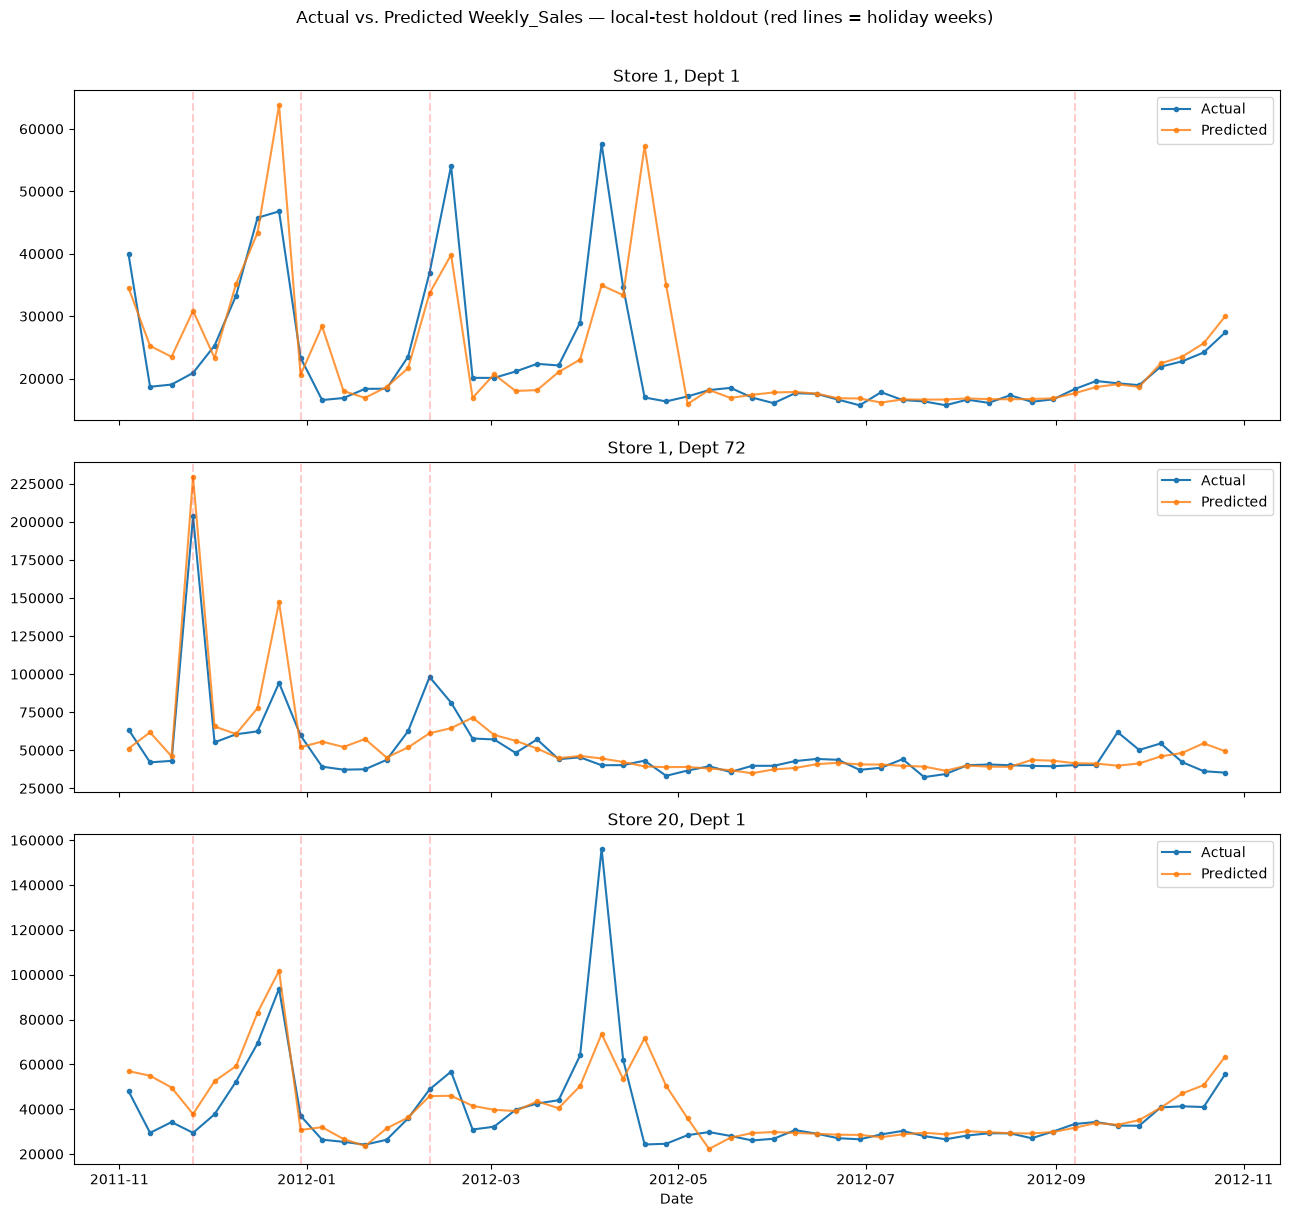

In [23]:
sample_combos = [(1, 1), (1, 72), (20, 1)]
holiday_dates_holdout = feat_local_test.loc[feat_local_test['IsHoliday'], 'Date'].unique()

fig, axes = plt.subplots(len(sample_combos), 1, figsize=(13, 4 * len(sample_combos)), sharex=True)
for ax, (store_id, dept_id) in zip(axes, sample_combos):
    s = feat_local_test[(feat_local_test.Store == store_id) & (feat_local_test.Dept == dept_id)].sort_values('Date')
    ax.plot(s['Date'], s['Weekly_Sales'], label='Actual', marker='o', markersize=3)
    ax.plot(s['Date'], s['Predicted'], label='Predicted', marker='o', markersize=3, alpha=0.8)
    for hd in holiday_dates_holdout:
        ax.axvline(pd.Timestamp(hd), color='red', alpha=0.2, linestyle='--')
    ax.set_title(f'Store {store_id}, Dept {dept_id}')
    ax.legend()
axes[-1].set_xlabel('Date')
plt.suptitle('Actual vs. Predicted Weekly_Sales — local-test holdout (red lines = holiday weeks)', y=1.01)
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


**Plot 2 — Feature importance** of the tuned model (gain).

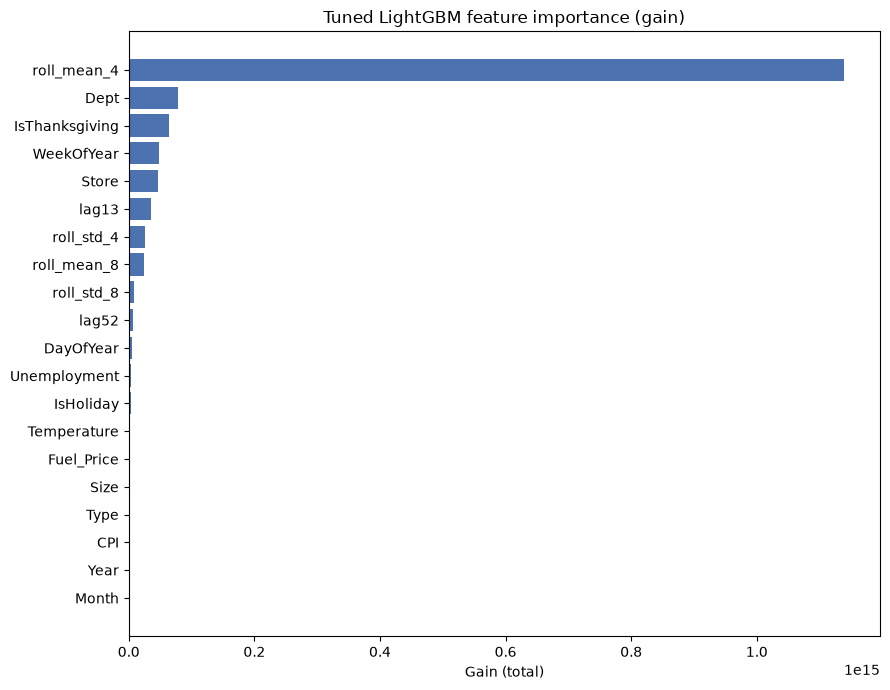

In [24]:
tuned_importance_df = pd.DataFrame({
    'feature': X_holdout_tr.columns,
    'gain': holdout_model.booster_.feature_importance(importance_type='gain'),
}).sort_values('gain', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))
plot_df = tuned_importance_df.iloc[::-1]
ax.barh(plot_df['feature'], plot_df['gain'], color='#4C72B0')
ax.set_xlabel('Gain (total)')
ax.set_title('Tuned LightGBM feature importance (gain)')
plt.tight_layout()
plt.savefig('plots/feature_importance_tuned.png', dpi=150)
plt.show()


**Plot 3 — WMAE by fold**, baseline (untuned) vs. tuned, to show CV stability and the effect of tuning.

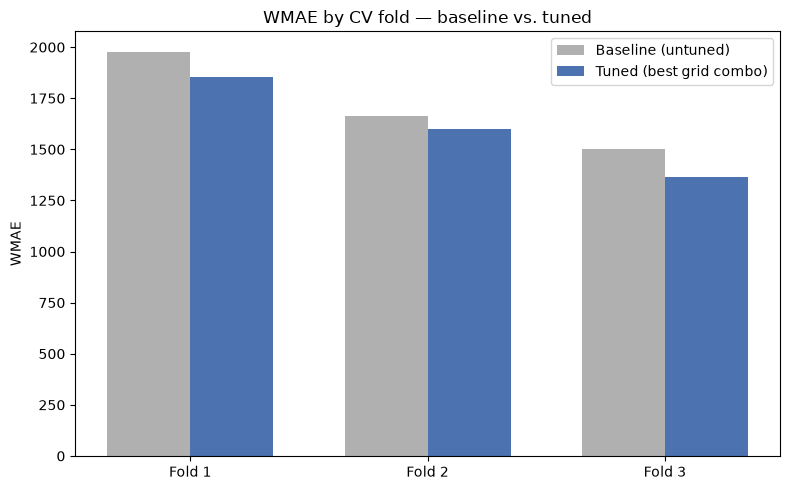

In [25]:
tuned_fold_wmaes = grid_results_df.loc[0, 'fold_wmaes']
baseline_fold_wmaes = cv_results_df['wmae'].tolist()

fold_labels = [f'Fold {i+1}' for i in range(len(baseline_fold_wmaes))]
x = np.arange(len(fold_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, baseline_fold_wmaes, width, label='Baseline (untuned)', color='#B0B0B0')
ax.bar(x + width / 2, tuned_fold_wmaes, width, label='Tuned (best grid combo)', color='#4C72B0')
ax.set_xticks(x)
ax.set_xticklabels(fold_labels)
ax.set_ylabel('WMAE')
ax.set_title('WMAE by CV fold — baseline vs. tuned')
ax.legend()
plt.tight_layout()
plt.savefig('plots/wmae_by_fold.png', dpi=150)
plt.show()


**Plot 4 — Residual distribution** on the local-test holdout.

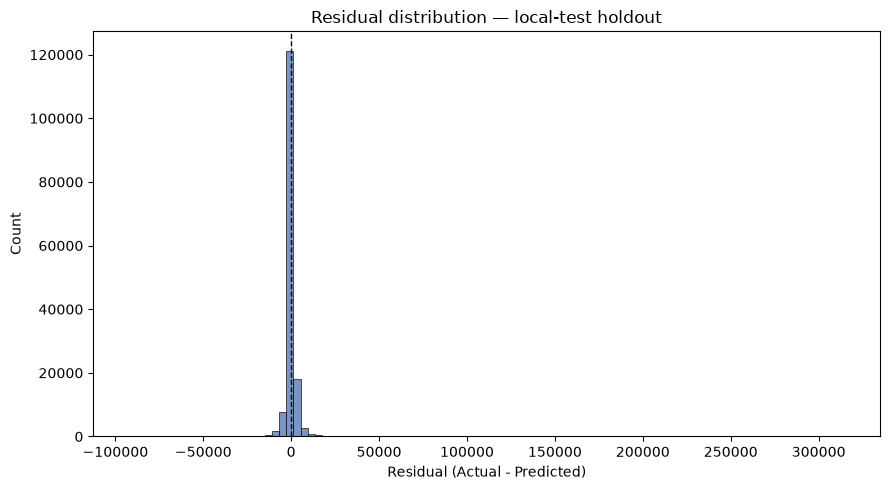

count    154386.000000
mean        -66.951632
std        3648.237918
min      -92247.931251
25%        -668.166239
50%         -34.937798
75%         547.759799
max      314537.210859
Name: Residual, dtype: float64


In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(feat_local_test['Residual'], bins=100, ax=ax, color='#4C72B0')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_title('Residual distribution — local-test holdout')
plt.tight_layout()
plt.savefig('plots/residual_distribution.png', dpi=150)
plt.show()

print(feat_local_test['Residual'].describe())


**Plot 5 — Actual vs. predicted, holiday vs. non-holiday weeks** — the metric's focus (holiday weeks are weighted 5x in WMAE).

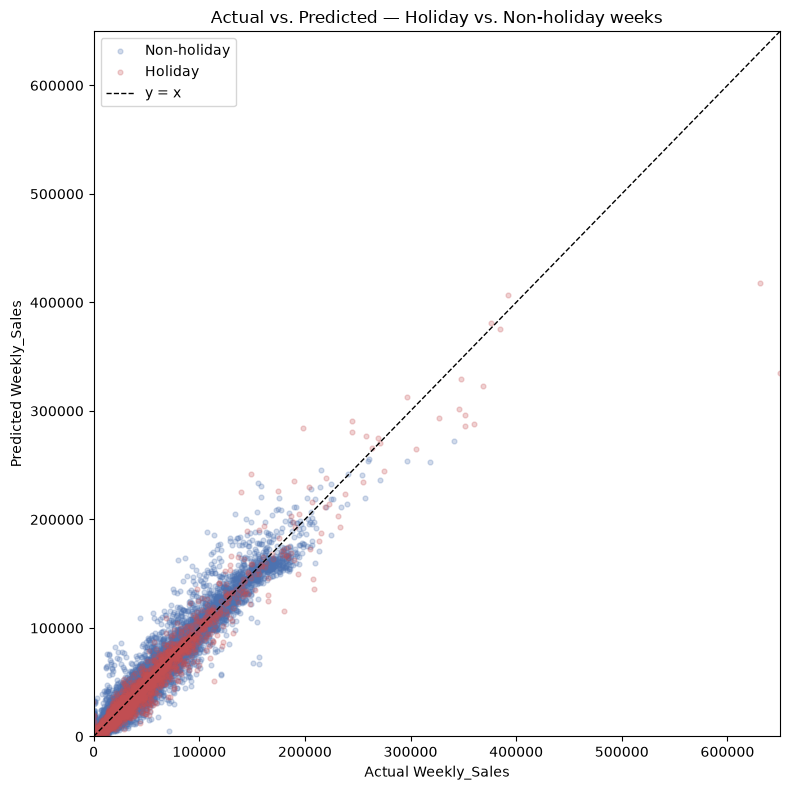

Unweighted MAE by week type:
IsHoliday
False    1489.459036
True     2106.412313
Name: abs_err, dtype: float64


In [27]:
fig, ax = plt.subplots(figsize=(8, 8))
for is_holiday, color, label in [(False, '#4C72B0', 'Non-holiday'), (True, '#C44E52', 'Holiday')]:
    subset = feat_local_test[feat_local_test['IsHoliday'] == is_holiday]
    ax.scatter(subset['Weekly_Sales'], subset['Predicted'], alpha=0.25, s=12, color=color, label=label)
lims = [0, feat_local_test[['Weekly_Sales', 'Predicted']].to_numpy().max()]
ax.plot(lims, lims, color='black', linewidth=1, linestyle='--', label='y = x')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual Weekly_Sales')
ax.set_ylabel('Predicted Weekly_Sales')
ax.set_title('Actual vs. Predicted — Holiday vs. Non-holiday weeks')
ax.legend()
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted_holiday.png', dpi=150)
plt.show()

mae_by_holiday = feat_local_test.assign(abs_err=feat_local_test['Residual'].abs()).groupby('IsHoliday')['abs_err'].mean()
print('Unweighted MAE by week type:')
print(mae_by_holiday)


<a id='8'></a>
## 8. Full Pipeline (Feature Engineering + Selection + Model)

A `sklearn.pipeline.Pipeline` of 3 steps, so the saved artifact is the whole
raw-input-to-prediction path, not just the bare LightGBM model:

1. `FeatureEngineeringTransformer` (`utils/feature_engineering.py`) — wraps
   `build_features` (merge with features.csv/stores.csv, calendar, lag,
   rolling). `features.csv`/`stores.csv` are baked in at construction time;
   the full raw training history is stored on `.fit()` so a later
   `.transform()`/`.predict()` call on bare, unmerged `Store/Dept/Date/IsHoliday`
   rows (e.g. `test.csv` as-is) has everything it needs for calendar-correct
   lag/rolling — no manual preprocessing required by the caller.
2. `FeatureSelector` — subsets to the 20 features chosen in Step 4.
3. The tuned `LGBMRegressor` (`FINAL_PARAMS` from Step 6) as the final estimator.

Fit on **all of `train.csv`** (`local_train_raw` + `local_test_raw` combined —
i.e. everything before the real Kaggle test set, now that CV/tuning/plots are
done and there's no more need to hold anything out).

In [28]:
from sklearn.pipeline import Pipeline
from utils.feature_engineering import FeatureEngineeringTransformer, FeatureSelector

full_pipeline = Pipeline([
    ('feature_engineering', FeatureEngineeringTransformer(features=features, stores=stores)),
    ('feature_selection', FeatureSelector(feature_names=selected_features)),
    ('model', LGBMRegressor(**FINAL_PARAMS)),
])

sw_full = np.where(train['IsHoliday'], 5, 1)
full_pipeline.fit(train, train['Weekly_Sales'], model__sample_weight=sw_full)
print('Pipeline fit on all of train.csv:', train.shape)


Pipeline fit on all of train.csv: (421570, 5)


**Confirm it truly takes raw input**: predict on a handful of bare rows
straight from `test.csv` — unmerged with `stores.csv`/`features.csv`, no
calendar/lag/rolling columns computed. If this works, `model_inference.ipynb`
(later, once other architectures are compared) can just load `test.csv` and
call `.predict()` directly.

In [29]:
raw_sample = test.head(5)
print('Raw input columns (exactly test.csv, nothing pre-computed):', list(raw_sample.columns))
raw_preds = full_pipeline.predict(raw_sample)
print('Predictions:', raw_preds)


Raw input columns (exactly test.csv, nothing pre-computed): ['Store', 'Dept', 'Date', 'IsHoliday']


Predictions: [34541.76199855 19964.37092261 20045.42759974 18725.32978199
 22738.58571382]


**Save to MLflow (DagsHub model registry)** inside a `LightGBM_Final_Fit`
run — `signature` is inferred straight from the raw input/output shapes above,
and `input_example` is that same small raw sample, so the registry entry
documents the true raw-input contract (`Store/Dept/Date/IsHoliday`), not the
20 engineered features.

In [30]:
from mlflow.models import infer_signature

signature = infer_signature(raw_sample, raw_preds)

with mlflow.start_run(run_name='LightGBM_Final_Fit'):
    mlflow.log_params(FINAL_PARAMS)
    mlflow.log_param('n_features', len(selected_features))
    mlflow.log_param('train_rows', len(train))
    mlflow.log_metric('local_holdout_wmae', holdout_wmae)

    mlflow.sklearn.log_model(
        full_pipeline,
        artifact_path='model',
        signature=signature,
        input_example=raw_sample,
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )

print('LightGBM_Final_Fit run logged, pipeline saved to MLflow model registry.')


/Users/r00t/ml-final-project/.venv/lib/python3.14/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


2026/07/22 07:53:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/07/22 07:53:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LightGBM_Final_Fit at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/0/runs/6e271375d35c4305b19950afc3d120f1
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/0


LightGBM_Final_Fit run logged, pipeline saved to MLflow model registry.


**Also save locally with `joblib`** under `models/`, as a backup independent of DagsHub/MLflow.

In [31]:
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(full_pipeline, 'models/lightgbm_pipeline.joblib')
print('Saved to models/lightgbm_pipeline.joblib')

reloaded = joblib.load('models/lightgbm_pipeline.joblib')
reloaded_preds = reloaded.predict(raw_sample)
print('Reloaded-pipeline predictions match:', np.allclose(reloaded_preds, raw_preds))


Saved to models/lightgbm_pipeline.joblib


Reloaded-pipeline predictions match: True
